In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

import zipfile

with zipfile.ZipFile('northstar_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('northstar_dataset')
customers = pd.read_csv('northstar_dataset/northstar_dataset/customers.csv')
orders = pd.read_csv('northstar_dataset/northstar_dataset/orders.csv')
deliveries = pd.read_csv('northstar_dataset/northstar_dataset/deliveries.csv')
complaints = pd.read_csv('northstar_dataset/northstar_dataset/complaints.csv')
incidents = pd.read_csv('northstar_dataset/northstar_dataset/incidents.csv')
drivers = pd.read_csv('northstar_dataset/northstar_dataset/drivers.csv')
vehicles = pd.read_csv('northstar_dataset/northstar_dataset/vehicles.csv')
hubs = pd.read_csv('northstar_dataset/northstar_dataset/hubs.csv')
app_events = pd.read_csv('northstar_dataset/northstar_dataset/app_events.csv')



In [3]:
deliveries.head()

complaints.head()

drivers.head()
deliveries.info()

complaints.info()
deliveries.isnull().sum()

complaints.isnull().sum()

drivers.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

,0
driver_id,0
base_zone,0
employment_type,0
years_experience,0
training_score,7
driver_rating,0
shift_preference,0
active_flag,0


In [4]:
deliveries.duplicated().sum()

complaints.duplicated().sum()


np.int64(0)

In [5]:
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time']
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at']
)

In [6]:
delivery_summary = deliveries['delivery_status'].value_counts()

print(delivery_summary)


delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


In [7]:
complaint_analysis = deliveries.merge(
    complaints,
    on='order_id',
    how='left'
)

complaint_analysis.groupby(
    ['delivery_status', 'severity']
).size()


delivery_status  severity
Delayed          High        12
                 Low          6
                 Medium      30
Failed           High        13
                 Low          5
                 Medium      17
OnTime           High        28
                 Low         35
                 Medium      86
dtype: int64

In [8]:
driver_analysis = deliveries.merge(
    drivers,
    on='driver_id',
    how='left'
)

driver_analysis[
    ['training_score',
     'driver_rating',
     'manual_route_override_count']
].corr()


,training_score,driver_rating,manual_route_override_count
training_score,1.000000,-0.043136,0.00964
driver_rating,-0.043136,1.000000,-0.02436
manual_route_override_count,0.009640,-0.024360,1.00000


In [9]:
fleet_analysis = deliveries.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

fleet_analysis.groupby(
    ['maintenance_status',
     'delivery_status']
).size()


maintenance_status  delivery_status
Active              Delayed            113
                    Failed              45
                    OnTime             384
InRepair            Delayed             52
                    Failed              77
                    OnTime             125
Scheduled           Delayed             37
                    Failed              10
                    OnTime             107
dtype: int64

In [10]:
hub_analysis = deliveries.merge(
    hubs,
    on='hub_id',
    how='left'
)

hub_complaints = hub_analysis.merge(
    complaints,
    on='order_id',
    how='left'
)

hub_complaints.groupby(
    ['hub_name', 'zone']
).agg({
    'delivery_id': 'count',
    'complaint_id': 'count'
})


,,delivery_id,complaint_id
hub_name,zone,,
Airport Hub,Airport,106,23
Central Core,Central,117,30
East Dock,East,121,33
Midtown Relay,Central,132,35
North Exchange,North,142,32
Riverside Hub,Riverside,118,33
South Link,South,108,18
West Gate,West,129,28


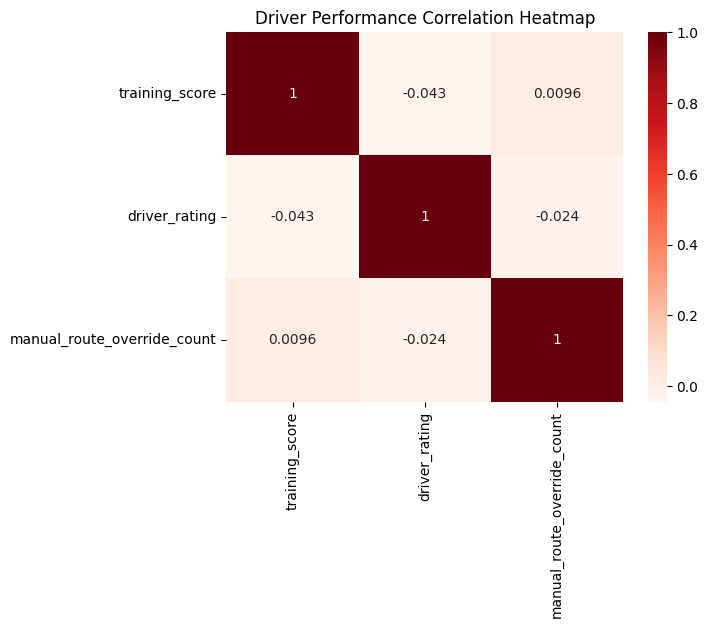

In [13]:
correlation_data = driver_analysis[
    [
        'training_score',
        'driver_rating',
        'manual_route_override_count'
    ]
]

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    cmap='Reds'
)

plt.title('Driver Performance Correlation Heatmap')

plt.show()

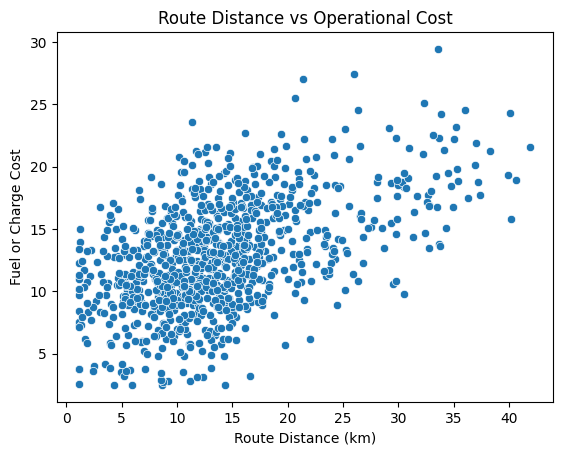

In [14]:
sns.scatterplot(
    data=deliveries,
    x='route_distance_km',
    y='fuel_or_charge_cost'
)

plt.title('Route Distance vs Operational Cost')

plt.xlabel('Route Distance (km)')

plt.ylabel('Fuel or Charge Cost')

plt.show()


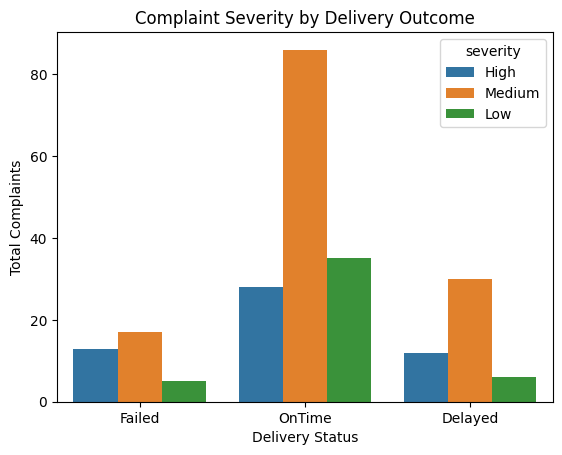

In [15]:
sns.countplot(
    data=complaint_analysis,
    x='delivery_status',
    hue='severity'
)

plt.title('Complaint Severity by Delivery Outcome')

plt.xlabel('Delivery Status')

plt.ylabel('Total Complaints')

plt.show()


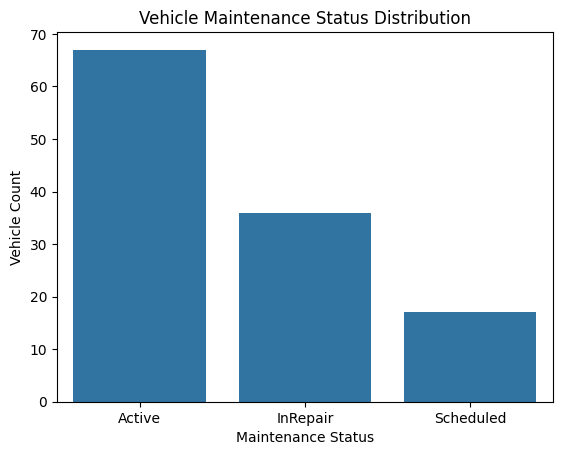

In [16]:
sns.countplot(
    data=vehicles,
    x='maintenance_status'
)

plt.title('Vehicle Maintenance Status Distribution')

plt.xlabel('Maintenance Status')

plt.ylabel('Vehicle Count')

plt.show()
